<a href="https://colab.research.google.com/github/AmalKhairalla/ML2-Activity-3/blob/main/pca%2Bdbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBSCAN + PCA ASSIGNMENT (STUDENT)

## 1. Import libraries

In [46]:
!pip install mglearn

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import mglearn
from sklearn.cluster import DBSCAN
# TODO: import required sklearn modules

## 2. Load Dataset

In [48]:
# TODO: load dataset
iris = load_iris()
df = pd.DataFrame(data = iris.data , columns= iris.feature_names)
df["speices"] = iris.target
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   speices  
0        0  
1        0  
2        0  
3        0  
4        0  


## 3. Preprocessing

In [49]:
# TODO:
# - Drop unnecessary columns
# - Handle missing values
# - Apply scaling
X_scaled = None

In [50]:
print( f"The shape of the Iris dataframe {df.shape}")
print(f"Numbers of rows (samples): {df.shape[0]}")
print(f"Numbers of columns (features + target): {df.shape[1]}")

The shape of the Iris dataframe (150, 5)
Numbers of rows (samples): 150
Numbers of columns (features + target): 5


In [51]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),speices
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
speices,0.782561,-0.426658,0.949035,0.956547,1.000000


The features are highly correlated with the target so i will keep them all

In [52]:
print(f"There is {df.isna().sum().sum()} nan values")
df.isna().sum()

There is 0 nan values


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
speices,0


In [53]:
X = df.drop(columns =["speices"])
y = df["speices"]

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

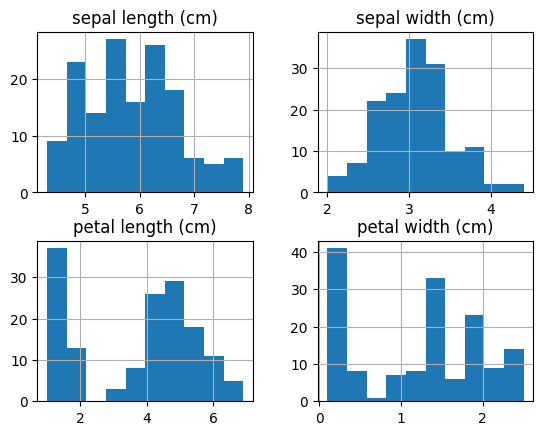

In [54]:
X.hist()

In [55]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)
x_scaled = pd.DataFrame(data = scaled_data , columns = X.columns )
x_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

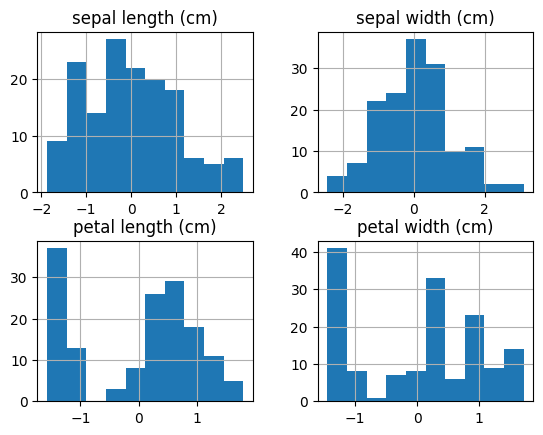

In [56]:
x_scaled.hist()

## 4. PCA

In [57]:
# TODO:
# - Apply PCA (2 components)
# - Print explained variance
X_pca = None
# TODO: Plot PCA

In [58]:
pca = PCA(n_components=2)

In [59]:
pca.fit(x_scaled)

PCA(n_components=2)

In [60]:
X_pca = pca.transform(x_scaled)
print("Original shape:", x_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


Text(0, 0.5, 'Second principal component')

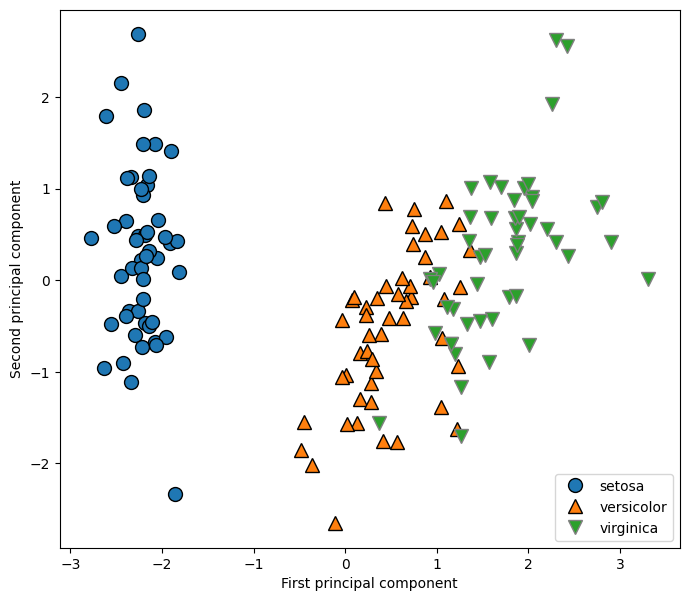

In [61]:
plt.figure(figsize=(8,8))
mglearn.discrete_scatter(X_pca[:,0], X_pca[:,1], iris.target)
plt.legend(iris.target_names, loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

In [62]:
print("PCA component shape:", pca.components_.shape)

PCA component shape: (2, 4)


In [63]:
print("PCA component:\n", pca.components_)

PCA component:
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


In [64]:
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

[2.93808505 0.9201649 ]
[0.72962445 0.22850762]


## 5. DBSCAN (Original Data)

In [65]:
# TODO:
# - Apply DBSCAN
# - Tune eps and min_samples
labels_original = None
# TODO: Plot clustering
# -------------------------------

In [66]:
X_scaled = x_scaled

In [67]:
dbscan_original = DBSCAN(eps=0.8, min_samples=5)

labels_original = dbscan_original.fit_predict(X_scaled)

labels_original

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [68]:
n_clusters_original = len(set(labels_original)) - (1 if -1 in labels_original else 0)
n_noise_original = list(labels_original).count(-1)

print("Number of clusters:", n_clusters_original)
print("Number of noise points:", n_noise_original)

Number of clusters: 2
Number of noise points: 4


I have Cluster 0

I also have Cluster 1

And a few points with a value of -1

This means we discovered that we have:

    2 clusters + some noise points

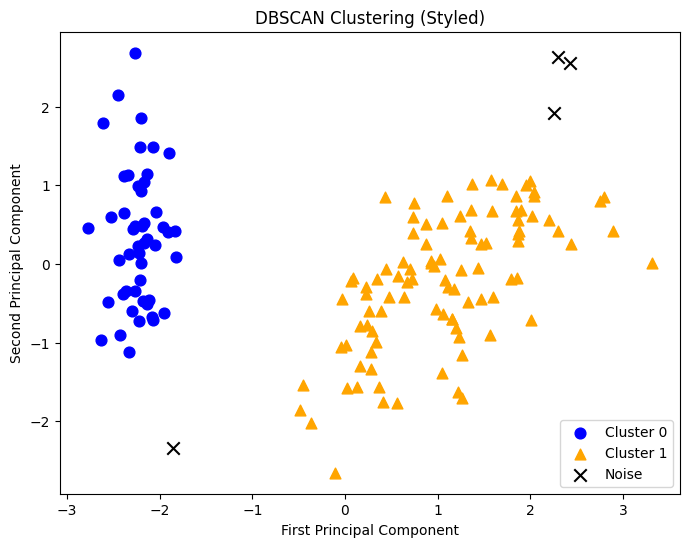

In [69]:
plt.figure(figsize=(8,6))

unique_labels = set(labels_original)

for label in unique_labels:

    if label == -1:
        # noise
        plt.scatter(
            X_pca[labels_original == label, 0],
            X_pca[labels_original == label, 1],
            c='black',
            marker='x',
            s=80,
            label='Noise'
        )

    elif label == 0:
        plt.scatter(
            X_pca[labels_original == label, 0],
            X_pca[labels_original == label, 1],
            c='blue',
            marker='o',
            s=60,
            label='Cluster 0'
        )

    elif label == 1:
        plt.scatter(
            X_pca[labels_original == label, 0],
            X_pca[labels_original == label, 1],
            c='orange',
            marker='^',
            s=60,
            label='Cluster 1'
        )

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("DBSCAN Clustering (Styled)")

plt.legend()
plt.show()

DBSCAN parameters must be tuned separately for the original dataset and the PCA-reduced dataset, since dimensionality reduction changes the data distribution and distances between points.

In [70]:
best_params_original = None
best_noise = float('inf')

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(x_scaled)

        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)


        if clusters == 2 and noise < best_noise:
            best_noise = noise
            best_params_original = (eps, min_samples)

print("Best parameters (Original):", best_params_original)
print("Minimum noise:", best_noise)

#هون خليت الكود يطلع افضل النتائج

Best parameters (Original): (1.0, 3)
Minimum noise: 1


In [71]:
results_original = []

eps_values = [0.3, 0.5, 0.6, 0.8, 1.0, 1.2]
min_samples_values = [3, 5, 7]

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(x_scaled)

        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)

        results_original.append([eps, min_samples, clusters, noise])

tuning_original = pd.DataFrame(
    results_original,
    columns=["eps", "min_samples", "Number of Clusters", "Noise Points"]
)

tuning_original
#وهون حبيت يدوي اشوف النتائج واخترت خيار افضل من الس هو اختاره

,eps,min_samples,Number of Clusters,Noise Points
0,0.3,3,10,84
1,0.3,5,3,120
2,0.3,7,2,129
3,0.5,3,7,17
4,0.5,5,2,34
5,0.5,7,5,46
6,0.6,3,4,9
7,0.6,5,2,26
8,0.6,7,2,32
9,0.8,3,2,4


For the original dataset, the best DBSCAN parameters were eps = 1.2 and min_samples = 5, as they produced 2 clusters with only 1 noise point, indicating a well-formed clustering with minimal outliers.

    Now I want to do a training session on the best parameters I came up with.

In [79]:
best_db_original = DBSCAN(eps=1.2, min_samples=5)

labels_original_best = best_db_original.fit_predict(x_scaled)

In [80]:
clusters_o = len(set(labels_original_best)) - (1 if -1 in labels_original_best else 0)
noise_o = list(labels_original_best).count(-1)

print("Final Original:")
print("Clusters:", clusters_o)
print("Noise:", noise_o)

Final Original:
Clusters: 2
Noise: 1


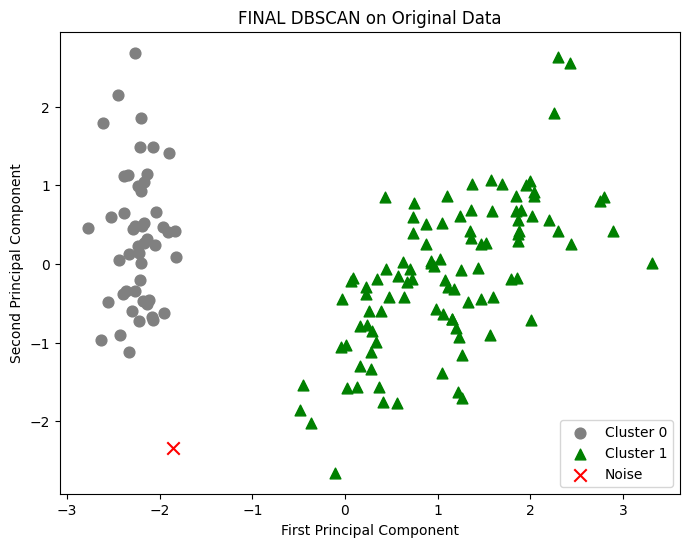

In [89]:
plt.figure(figsize=(8,6))

unique_labels = set(labels_original_best)

for label in unique_labels:

    if label == -1:
        plt.scatter(
            X_pca[labels_original_best == label, 0],
            X_pca[labels_original_best == label, 1],
            c='red',
            marker='x',
            s=80,
            label='Noise'
        )

    elif label == 0:
        plt.scatter(
            X_pca[labels_original_best == label, 0],
            X_pca[labels_original_best == label, 1],
            c='gray',
            marker='o',
            s=60,
            label='Cluster 0'
        )

    elif label == 1:
        plt.scatter(
            X_pca[labels_original_best == label, 0],
            X_pca[labels_original_best == label, 1],
            c='green',
            marker='^',
            s=60,
            label='Cluster 1'
        )

plt.title("FINAL DBSCAN on Original Data")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.legend()
plt.show()

## 6. DBSCAN (PCA Data)

In [72]:
labels_pca = None
# TODO: Plot clustering

In [73]:
dbscan_pca = DBSCAN(eps=0.6, min_samples=5)

labels_pca = dbscan_pca.fit_predict(X_pca)

labels_pca

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [74]:
n_clusters_pca = len(set(labels_pca)) - (1 if -1 in labels_pca else 0)
n_noise_pca = list(labels_pca).count(-1)

print("Number of clusters:", n_clusters_pca)
print("Number of noise points:", n_noise_pca)

Number of clusters: 2
Number of noise points: 6


After applying DBSCAN on both the original scaled data and the PCA-reduced data, the number of clusters remained the same (2 clusters). However, the number of noise points increased from 4 to 6 after applying PCA. This indicates that dimensionality reduction caused some loss of information, making certain data points less dense and more likely to be classified as noise.

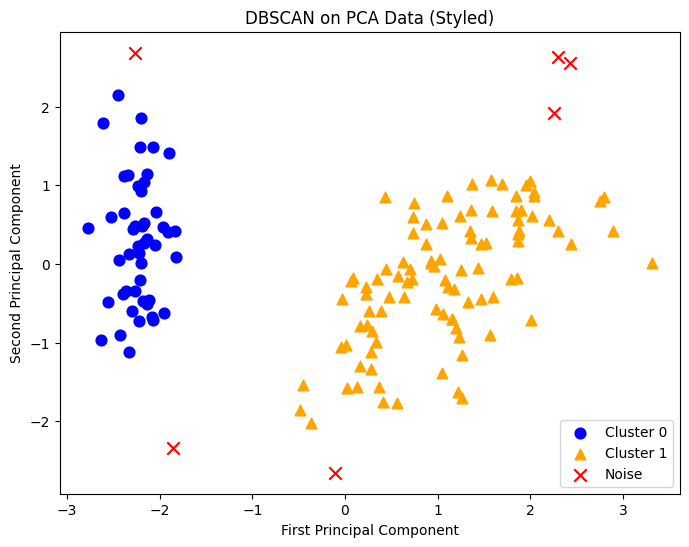

In [75]:
plt.figure(figsize=(8,6))

unique_labels = set(labels_pca)

for label in unique_labels:

    if label == -1:
        # noise
        plt.scatter(
            X_pca[labels_pca == label, 0],
            X_pca[labels_pca == label, 1],
            c='red',
            marker='x',
            s=80,
            label='Noise'
        )

    elif label == 0:
        plt.scatter(
            X_pca[labels_pca == label, 0],
            X_pca[labels_pca == label, 1],
            c='blue',
            marker='o',
            s=60,
            label='Cluster 0'
        )

    elif label == 1:
        plt.scatter(
            X_pca[labels_pca == label, 0],
            X_pca[labels_pca == label, 1],
            c='orange',
            marker='^',
            s=60,
            label='Cluster 1'
        )

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("DBSCAN on PCA Data (Styled)")

plt.legend()
plt.show()

DBSCAN parameters must be tuned separately for the original dataset and the PCA-reduced dataset, since dimensionality reduction changes the data distribution and distances between points.

In [76]:
best_params_pca = None
best_noise_pca = float('inf')

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca)

        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)

        if clusters == 2 and noise < best_noise_pca:
            best_noise_pca = noise
            best_params_pca = (eps, min_samples)

print("Best parameters (PCA):", best_params_pca)
print("Minimum noise:", best_noise_pca)

#هون خليت الكود يطلع افضل النتائج

Best parameters (PCA): (1.0, 3)
Minimum noise: 1


In [77]:
results_pca = []

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca)

        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)

        results_pca.append([eps, min_samples, clusters, noise])

tuning_pca = pd.DataFrame(
    results_pca,
    columns=["eps", "min_samples", "Number of Clusters", "Noise Points"]
)

tuning_pca

#وهون حبيت يدوي اشوف النتائج واخترت خيار افضل من الس هو اختاره

,eps,min_samples,Number of Clusters,Noise Points
0,0.3,3,5,19
1,0.3,5,5,33
2,0.3,7,4,61
3,0.5,3,2,7
4,0.5,5,2,12
5,0.5,7,2,15
6,0.6,3,2,5
7,0.6,5,2,6
8,0.6,7,2,9
9,0.8,3,3,1


Although both parameter sets (eps=1.0, min_samples=3) and (eps=1.2, min_samples=5) produced the same number of noise points, the latter was selected because it provides more stable clustering and is less sensitive to small local variations in the data.

    Now I want to do a training session on the best parameters I came up with.

In [82]:
best_db_pca = DBSCAN(eps=1.2, min_samples=5)

labels_pca_best = best_db_pca.fit_predict(X_pca)

In [83]:
clusters_p = len(set(labels_pca_best)) - (1 if -1 in labels_pca_best else 0)
noise_p = list(labels_pca_best).count(-1)

print("\nFinal PCA:")
print("Clusters:", clusters_p)
print("Noise:", noise_p)


Final PCA:
Clusters: 2
Noise: 1


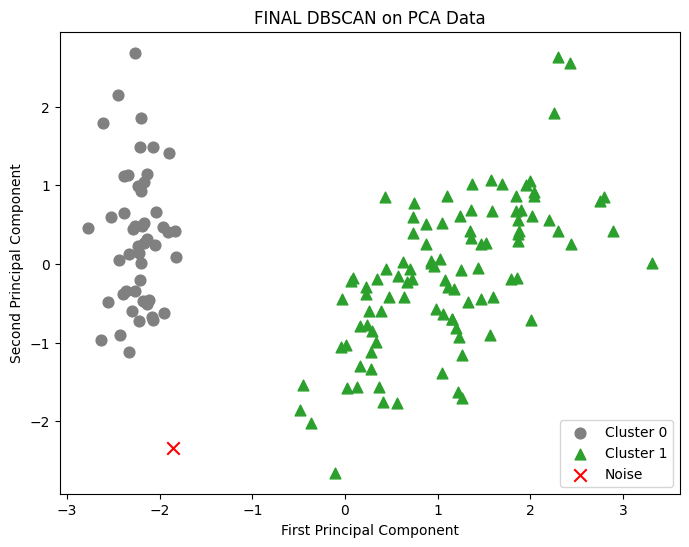

In [91]:
plt.figure(figsize=(8,6))

unique_labels = set(labels_pca_best)

for label in unique_labels:

    if label == -1:
        plt.scatter(
            X_pca[labels_pca_best == label, 0],
            X_pca[labels_pca_best == label, 1],
            c='red',
            marker='x',
            s=80,
            label='Noise'
        )

    elif label == 0:
        plt.scatter(
            X_pca[labels_pca_best == label, 0],
            X_pca[labels_pca_best == label, 1],
            c='gray',
            marker='o',
            s=60,
            label='Cluster 0'
        )

    elif label == 1:
        plt.scatter(
            X_pca[labels_pca_best == label, 0],
            X_pca[labels_pca_best == label, 1],
            c='#2ca02c',
            marker='^',
            s=60,
            label='Cluster 1'
        )

plt.title("FINAL DBSCAN on PCA Data")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.legend()
plt.show()

### 7. Analysis

In [78]:
# TODO:
# - Compare results
# - Count clusters
# - Count noise points
print("Analysis goes here")

Analysis goes here


** Comparison between Original Data and PCA

DBSCAN was applied on both the original scaled dataset and the PCA-reduced dataset to evaluate the effect of dimensionality reduction on clustering performance.

For the original dataset, the optimal parameters (eps = 1.2, min_samples = 5) produced 2 clusters with only 1 noise point. Similarly, for the PCA-reduced dataset, the same parameters resulted in 2 clusters and 1 noise point, indicating consistent clustering performance.

Although the dataset contains three true classes (setosa, versicolor, and virginica), DBSCAN identified only two clusters. This is because DBSCAN is a density-based algorithm that does not use class labels. The setosa class is clearly separated, while versicolor and virginica overlap significantly, causing them to be grouped into a single cluster.

** Effect of PCA
PCA was used to reduce the dimensionality of the dataset from 4 features to 2 principal components. This allowed for easier visualization of the data.

The PCA scatter plot showed three distinguishable groups when colored using the true labels. However, some overlap between versicolor and virginica was still visible.

Despite dimensionality reduction, DBSCAN produced similar clustering results on both the original and PCA-reduced datasets. This indicates that PCA preserved the essential structure of the data.

** Noise Detection
DBSCAN successfully identified noise points in both datasets. The number of noise points was minimal when optimal parameters were used, indicating that most data points belong to well-defined clusters.

** Strengths & Limitations
One of the main strengths of DBSCAN is its ability to detect noise and discover clusters of arbitrary shapes without requiring the number of clusters in advance.

However, DBSCAN is sensitive to parameter selection, especially eps. Additionally, it may struggle with datasets where clusters have varying densities or overlapping regions, as observed with versicolor and virginica.

In conclusion, DBSCAN combined with PCA provides an effective approach for clustering and visualizing data. PCA simplifies the data while preserving its structure, and DBSCAN identifies meaningful clusters and noise points.

Although DBSCAN did not perfectly match the true class labels, it revealed the underlying density-based structure of the dataset. Proper parameter tuning was essential to achieving optimal clustering results.